<a href="https://colab.research.google.com/github/ansonkwokth/TableTennisPrediction/blob/dev/calibration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/ansonkwokth/TableTennisPrediction.git
%cd TableTennisPrediction

Cloning into 'TableTennisPrediction'...
remote: Enumerating objects: 352, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 352 (delta 27), reused 15 (delta 15), pack-reused 311 (from 2)
Receiving objects: 100% (352/352), 6.01 MiB | 8.62 MiB/s, done.
Resolving deltas: 100% (173/173), done.
/content/TableTennisPrediction


In [2]:

import pandas as pd
from utils import data_loader as dl

import numpy as np
from model.Elo import Elo
from model.ModifiedElo import ModifiedElo
from model.ensemble import BaggingRatingSystem

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import copy
from scipy.interpolate import interp1d

import warnings
warnings.filterwarnings('ignore')

# Data

In [177]:
# GAME = 'TTStar'
# GAME = 'TTCup'
# GAME = 'SetkaCup'
GAME = 'SetkaCupWomen'
# GAME = 'LigaPro'


In [5]:
match GAME:
    case 'TTStar':
        years = [2020, 2021, 2022, 2023, 2024]
    case 'TTCup':
        years = [2020, 2021, 2022, 2023, 2024]
    case 'SetkaCup':
        years = [2020, 2021, 2022, 2023, 2024]
    case 'SetkaCupWomen':
        years = [2020, 2021, 2022, 2023, 2024]
    case 'LigaPro':
        years = [2022, 2023, 2024]
    case _:
        raise ValueError("Invalid game selected.")


text_data_game = dl.load_game_data(GAME, years, '../')
text_data = {
    year: text_data_game[year] for year in years
}
df = dl.create_game_dfs(GAME, years, text_data)

Loading ..//SetkaCupWomen2020.txt
Loading ..//SetkaCupWomen2021.txt
Loading ..//SetkaCupWomen2022.txt
Loading ..//SetkaCupWomen2023.txt
Loading ..//SetkaCupWomen2024.txt


In [6]:
# Generate ID indices for each pair of rows in the DataFrame
idx_lt = [i for i in range(len(df) // 2) for _ in range(2)]
df['ID'] = idx_lt  # Assign to the 'ID' column

# Reset the DataFrame index to ensure it's sequential
df.reset_index(drop=True, inplace=True)

# Get unique players and store them in player_lt
player_lt = df['Player'].unique()



In [7]:
year_val = years[-2]
year_test = years[-1]

df_train = df.loc[pd.DatetimeIndex(df['Date']).year < year_val]
df_val = df.loc[pd.DatetimeIndex(df['Date']).year == year_val]
df_test = df.loc[pd.DatetimeIndex(df['Date']).year == year_test]

In [8]:
def format_to_array(df: pd.DataFrame) -> np.ndarray:

    # info_col = ['ID', 'Round', 'Datetime', 'Game', 'Date', 'Time']
    info_col = ['Round', 'Datetime', 'Game', 'Date', 'Time']
    col = [item for item in df.columns if item not in info_col]

    df[[c for c in col if "Set" in c]] = df[[c for c in col if "Set" in c]].astype(float)
    X = df[col].values.reshape(-1, 2, len(col))
    return X

In [9]:
X_train = format_to_array(df_train)
X_val = format_to_array(df_val)
X_test = format_to_array(df_test)

In [10]:
X_all = format_to_array(df)

# Train and Evaluate

In [12]:
modelMElo = ModifiedElo()
for _ in range(5):
    modelMElo.fit(X_train)

Training model: 100%|██████████| 26120/26120 [00:01<00:00, 17957.88it/s]


In [145]:
def get_cal(model, dataset):
    print(f"Evaluate model: {repr(model)}")
    _model = copy.deepcopy(model)
    _model.verbose = False

    history = []
    predictions = []

    for idx, matchi in tqdm(enumerate(dataset), desc="Evaluating matches"):
    # for idx, matchi in enumerate(dataset):
        id = matchi[0, 0]
        matchi = matchi.T
        player1, player2 = matchi[1]

        found_p1, found_p2, p = _model.predict_point(player1, player2)
        if not (found_p1 and found_p2): continue
        if p == 0.5: continue

        for seti in matchi[2:]:
            if np.isnan(seti[0]) or (seti[0] + seti[1]) == 0: break
            winrate = seti[0] / (seti[0] + seti[1])
            history.append(winrate)
            predictions.append(p)

    return np.array(history), np.array(predictions)

In [178]:
histo, pred = get_cal(modelMElo, X_val)
histo_test, pred_test = get_cal(modelMElo, X_test)

Evaluate model: ModifiedElo(learning_rate=0.1, base_param=(0, 1), update_sigma=True, verbose=False)


Evaluating matches: 6490it [00:00, 55721.54it/s]


Evaluate model: ModifiedElo(learning_rate=0.1, base_param=(0, 1), update_sigma=True, verbose=False)


Evaluating matches: 1969it [00:00, 68671.03it/s]


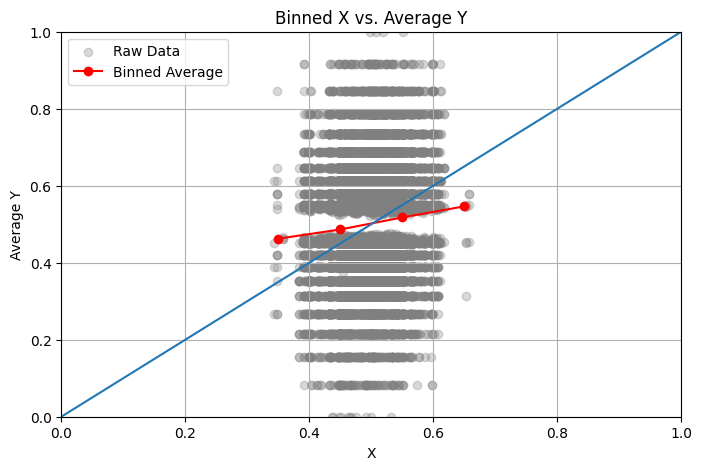

In [180]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate sample data
# np.random.seed(42)
# data = np.random.rand(100, 2)  # 100 rows of (x, y) values between 0 and 1

# Convert to DataFrame
df = pd.DataFrame(np.array([pred, histo]).T, columns=['x', 'y'])

# Define bins
bin_size = 0.1
bins = np.arange(0, 1+bin_size, bin_size)  # Bins from 0 to 1 with step 0.1

# Assign each x value to a bin
df['x_bin'] = pd.cut(df['x'], bins=bins, labels=bins[:-1] + bin_size/2, include_lowest=True)

# Compute the average y-value for each bin
binned_data = df.groupby('x_bin')['y'].mean().reset_index()

# Convert 'x_bin' back to numeric
binned_data['x_bin'] = binned_data['x_bin'].astype(float)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df['x'], df['y'], alpha=0.3, label="Raw Data", color="gray")  # Raw data points
plt.plot(binned_data['x_bin'], binned_data['y'], marker='o', linestyle='-', color='red', label="Binned Average")

plt.xlabel("X")
plt.ylabel("Average Y")
plt.title("Binned X vs. Average Y")
plt.legend()
plt.grid()
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.plot([0,1], [0,1])
plt.show()


In [206]:
def calibrated_p(logit_p, A=1):
    return 1/(1 + np.exp(-A*logit_p))

In [290]:
A = 1
nu = 0.05
A_prev = A
logit_pred = np.log(pred/(1-pred))
for _ in range(10000):
    A = A - nu* np.mean((calibrated_p(logit_pred, A) - histo))

    # print(np.mean(calibrated_p(logit_pred, A) - histo))
    print(abs(A - A_prev))
    if abs(A - A_prev) < 1e-4: print("break"); break
    A_prev = A
    # print(A)

Streaming output truncated to the last 5000 lines.
0.00011210055831756272
0.00011209809877654742
0.00011209563924929888
0.00011209317973581712
0.00011209072023610211
0.00011208826075015388
0.00011208580127775036
0.00011208334181933566
0.00011208088237446567
0.00011207842294336245
0.00011207596352624805
0.00011207350412267836
0.00011207104473287544
0.00011206858535683928
0.00011206612599456989
0.00011206366664606726
0.0001120612073113314
0.0001120587479903623
0.00011205628868315998
0.00011205382938950237
0.00011205137010983357
0.00011204891084393154
0.00011204645159157423
0.00011204399235320572
0.00011204153312838194
0.00011203907391754697
0.00011203661472025672
0.00011203415553695528
0.00011203169636719856
0.00011202923721143065
0.00011202677806920747
0.00011202431894097309
0.00011202185982628343
0.00011201940072536054
0.00011201694163842646
0.0001120144825650371
0.0001120120235054145
0.00011200956445978072
0.00011200710542769166
0.00011200464640936936
0.00011200218740503587
0.00011199

In [291]:
np.sum(histo * np.log(pred) + (1-histo) * np.log(1-pred))

-14602.004275514795

In [292]:
np.sum(histo * np.log(calibrated_p(logit_pred, 1/A)) + (1-histo) * np.log(1-calibrated_p(logit_pred, 1/A)))

-14579.383083364046

In [293]:
np.sum(histo * np.log(calibrated_p(logit_pred, A)) + (1-histo) * np.log(1-calibrated_p(logit_pred, A)))

-14776.081230343369

In [289]:
A

390.1483063721831

390.1483063721831

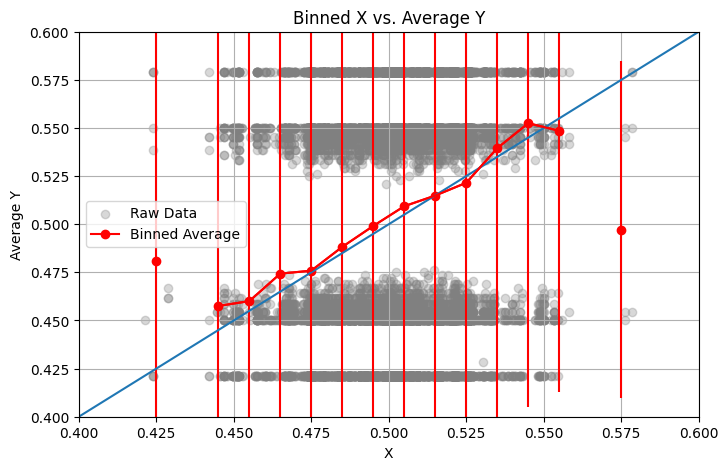

In [297]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate sample data
# np.random.seed(42)
# data = np.random.rand(100, 2)  # 100 rows of (x, y) values between 0 and 1


# Convert to DataFrame
df = pd.DataFrame(np.array([calibrated_p(logit_pred, 1/A), histo]).T, columns=['x', 'y'])

# Define bins
bin_size = 0.01
bins = np.arange(0, 1+bin_size, bin_size)  # Bins from 0 to 1 with step 0.1

# Assign each x value to a bin
df['x_bin'] = pd.cut(df['x'], bins=bins, labels=bins[:-1] + bin_size/2, include_lowest=True)

# Compute the average y-value for each bin
binned_data = df.groupby('x_bin')['y'].mean().reset_index()
binned_data_std = df.groupby('x_bin')['y'].std().reset_index()['y'].astype(float)

# Convert 'x_bin' back to numeric
binned_data['x_bin'] = binned_data['x_bin'].astype(float)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df['x'], df['y'], alpha=0.3, label="Raw Data", color="gray")  # Raw data points
plt.plot(binned_data['x_bin'], binned_data['y'], marker='o', linestyle='-', color='red', label="Binned Average")
plt.errorbar(binned_data['x_bin'], binned_data['y'], binned_data_std, color='red')

plt.xlabel("X")
plt.ylabel("Average Y")
plt.title("Binned X vs. Average Y")
plt.legend()
plt.grid()
plt.xlim(0.4, 0.6)
plt.ylim(0.4, 0.6)
# plt.xlim(0, 1)
# plt.ylim(0, 1)
plt.plot([0,1], [0,1])
plt.show()


In [279]:
A

2.0479607217049844

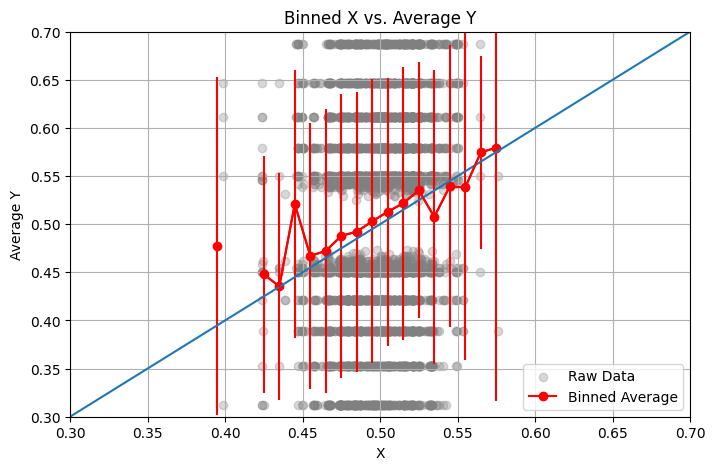

In [300]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate sample data
# np.random.seed(42)
# data = np.random.rand(100, 2)  # 100 rows of (x, y) values between 0 and 1


# Convert to DataFrame
logit_pred_test = np.log(pred_test/(1-pred_test))
df_test = pd.DataFrame(np.array([calibrated_p(logit_pred_test, 1/A), histo_test]).T, columns=['x', 'y'])
# df_test = pd.DataFrame(np.array([pred_test, histo_test]).T, columns=['x', 'y'])

# Define bins
# bin_size = 0.05
# bins = np.arange(0, 1+bin_size, bin_size)  # Bins from 0 to 1 with step 0.1

# Assign each x value to a bin
df_test['x_bin'] = pd.cut(df_test['x'], bins=bins, labels=bins[:-1] + bin_size/2, include_lowest=True)

# Compute the average y-value for each bin
binned_data_test = df_test.groupby('x_bin')['y'].mean().reset_index()
binned_data_test_std = df_test.groupby('x_bin')['y'].std().reset_index()['y'].astype(float)

# Convert 'x_bin' back to numeric
binned_data_test['x_bin'] = binned_data_test['x_bin'].astype(float)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(df_test['x'], df_test['y'], alpha=0.3, label="Raw Data", color="gray")  # Raw data points
plt.plot(binned_data_test['x_bin'], binned_data_test['y'], marker='o', linestyle='-', color='red', label="Binned Average")
plt.errorbar(binned_data_test['x_bin'], binned_data_test['y'], binned_data_test_std, color='red')


plt.xlabel("X")
plt.ylabel("Average Y")
plt.title("Binned X vs. Average Y")
plt.legend()
plt.grid()
plt.xlim(0.3, 0.7)
plt.ylim(0.3, 0.7)
# plt.xlim(0.4, 0.6)
# plt.ylim(0.4, 0.6)
# plt.xlim(0, 1)
# plt.ylim(0, 1)
plt.plot([0,1], [0,1])
plt.show()


In [332]:
p_p = np.linspace(0, 1, 10000)
p_s = sum(modelElo.predict_set_config_from_p(p_p).values())

In [333]:
def find_closest_x(array, target_y):
    # Convert to numpy array for easier manipulation
    array = np.array(array)

    # Find the index where y is closest to target_y
    index = np.argmin(np.abs(array[:, 1] - target_y))

    # Return the corresponding x value
    return array[index, 0]

In [338]:
p_search = 0.9
p_found = find_closest_x(np.array([p_p, p_s]).T, p_search)

In [339]:
sum(modelElo.predict_set_config_from_p(p_found).values())

0.8999528312320759